# Setup

### Imports

In [148]:
# !pip install -r ../requirements.txt

In [149]:
# ---- Standard libraries ----
import os
import sys
import json
import csv
import time
import math
import ast
import copy
import heapq
import random
import pickle
import logging
from datetime import datetime
from collections import defaultdict, namedtuple, deque
from itertools import permutations
from dataclasses import dataclass, field
from typing import Any, Optional, List, Dict

# ---- Data manipulation / visualization ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm

# ---- Geo-related ----
import geojson
import geopandas as gpd
from shapely.geometry import Point, Polygon
from alphashape import alphashape
import geopy.distance
import networkx as nx
import requests
import overpass  # Overpass API for OpenStreetMap queries

# ---- PyTorch (for RL/deep learning parts) ----
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ---- Removed: this line (was for Colab only) ----
# from google.colab import drive


# Parameters for simulations

In [ ]:
# params
ndrivers = 9000
ndeleveries = 9324
thresh_del = 30
baseline = "maddpg" # umst or maddpg

state_name = "Ohio" 
city_name = "Columbus"
mini = True

# Everything Else

### Paths

In [175]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

# Local data folder
DATA_DIR = PROJECT_ROOT / "Delivery_Data"
DATA_DIR.mkdir(exist_ok=True)

print(f"Using data directory: {DATA_DIR}")

Using data directory: c:\Vishwam\APPCAIR\UMST_approach\Delivery_Data


In [176]:
# --- 5. Set Directories (local/cloud version) ---
from pathlib import Path
import os

try:
    # Step 1: base path (one level up from "Source Code/")
    personal_dir = str(Path.cwd().parent / "Delivery_Data") + "/"

    # Step 2: data folder based on city_name and mini flag
    data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"

    # Step 3: output folder (same structure as before)
    output_dir = data_dir + "/UMST Graph/maddpg_baseline"

    # Step 4: create output directory if missing
    os.makedirs(output_dir, exist_ok=True)

    # Step 5: print info
    print(f"Data directory: {data_dir}")
    print(f"Output directory: {output_dir}")

    # Step 6: list contents for sanity check
    data = os.listdir(data_dir)
    print(f"Files in data_dir: {data}")

except Exception as e:
    print(f"Error setting up directories: {e}")
    print(f"Personal Dir Path: {personal_dir}")
    print(f"Data Dir Path: {data_dir}")

Data directory: c:\Vishwam\APPCAIR\UMST_approach\Delivery_Data/Columbus_mini - RL Delivery Data
Output directory: c:\Vishwam\APPCAIR\UMST_approach\Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/maddpg_baseline
Files in data_dir: ['avg_hotspot_data.json', 'Census Data', 'Deliveries', 'gh_cache', 'Hotspot Data', 'Images', 'Original Location Data', 'Processed Location Data', 'Q Tables', 'results_fixed_buffer', 'results_multiply', 'results_randomized', 'results_rangewise', 'UMST Graph']


In [177]:
graph_path = data_dir + "/UMST Graph/graphs"
full_graph = graph_path + "/gh_hotspot_graph.graphml.xml"
umst_graph = graph_path + "/umst_graph.graphml.xml"

### Sanity Check

In [178]:
import networkx as nx
import numpy as np

def verify_hotspot_graph(graph_path):
    """
    Load and verify the hotspot graph.
    Ensures node and edge attributes are valid and consistent.
    Returns: nx.Graph object if valid.
    """
    print(f"\n📂 Loading graph from: {graph_path}")
    try:
        G = nx.read_graphml(graph_path)
    except Exception as e:
        raise ValueError(f"❌ Failed to load graph: {e}")

    # Basic info
    print(f"✓ Graph loaded successfully.")
    print(f"   → {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # --- Node checks ---
    missing_latlon = [
        n for n, d in G.nodes(data=True)
        if 'lat' not in d or 'lon' not in d
    ]
    if missing_latlon:
        raise ValueError(f"❌ Some nodes missing lat/lon: {missing_latlon[:5]}")
    else:
        print(f"✓ All nodes have lat/lon attributes.")

    # --- Edge checks ---
    bad_edges = []
    distances, times = [], []
    for u, v, d in G.edges(data=True):
        dist = float(d.get('distance', np.nan))
        time = float(d.get('time', np.nan))
        if np.isnan(dist) or np.isnan(time) or dist <= 0 or time <= 0:
            bad_edges.append((u, v, d))
        else:
            distances.append(dist)
            times.append(time)

    if bad_edges:
        print(f"⚠️ Found {len(bad_edges)} edges with invalid data. Showing first 3:")
        for e in bad_edges[:3]:
            print("   ", e)
    else:
        print(f"✓ All edges have valid distance/time attributes.")

    print(f"📊 Mean distance: {np.mean(distances):.2f} km")
    print(f"📊 Mean travel time: {np.mean(times):.1f} mins")
    sample_edge = list(G.edges(data=True))[0]
    print(f"🔍 Sample edge: {sample_edge}")

    return G


In [179]:
if(baseline == "umst"):
    gtype = umst_graph
else:
    gtype = umst_graph #full_graph
G = verify_hotspot_graph(gtype)


📂 Loading graph from: c:\Vishwam\APPCAIR\UMST_approach\Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/umst_graph.graphml.xml
✓ Graph loaded successfully.
   → 26 nodes, 47 edges
✓ All nodes have lat/lon attributes.
✓ All edges have valid distance/time attributes.
📊 Mean distance: 1.80 km
📊 Mean travel time: 4.1 mins
🔍 Sample edge: ('39049001110', '39049001000', {'weight': 0.7133257288090575, 'distance': 1.016, 'time': 3.45, 'mst_frequency': 36, 'frequency_ratio': 0.9})


## Delivery Class

In [180]:
@dataclass
class Delivery:
    id: int
    pickup: Any           # node id (string or int depending on your graph)
    dropoff: Any          # node id
    status: str = "waiting"  # one of: waiting, assigned, in_transit, completed, cancelled
    owner: Optional[int] = None    # agent_id if assigned (None if not)

    # --- Time fields (all in minutes, filled by the environment) ---
    spawn_time: Optional[float] = None        # when delivery enters the system
    pickup_time: Optional[float] = None       # when a driver starts serving it
    completion_time: Optional[float] = None   # when it is delivered

    metadata: Dict = field(default_factory=dict)
    
    def assign_to_agent(self, agent_id: int):
        """Mark this delivery as assigned to a given agent."""
        self.owner = agent_id
        self.status = "assigned"
    
    def start_transport(self):
        """Mark that the delivery is now being actively transported."""
        self.status = "in_transit"
    
    def complete(self):
        """Mark this delivery as completed. The env will set completion_time."""
        self.status = "completed"
    
    def to_dict(self):
        return {
            "id": self.id,
            "pickup": self.pickup,
            "dropoff": self.dropoff,
            "status": self.status,
            "owner": self.owner,
            "spawn_time": self.spawn_time,
            "pickup_time": self.pickup_time,
            "completion_time": self.completion_time,
            "metadata": self.metadata
        }
    
    def __repr__(self):
        return (
            f"Delivery(id={self.id}, {self.pickup}->{self.dropoff}, "
            f"status={self.status}, owner={self.owner})"
        )


In [181]:
class DeliveryList:
    """
    A small manager/wrapper around a list of Delivery objects.
    Provides convenience lookups by node (pickup map) and by id.
    """
    def __init__(self, deliveries: Optional[List[Delivery]] = None):
        self.deliveries: List[Delivery] = deliveries[:] if deliveries else []
        self.by_id: Dict[int, Delivery] = {d.id: d for d in self.deliveries}
        self.pickup_map: Dict[Any, List[int]] = {}   # node -> list of delivery ids (waiting)
        self._rebuild_pickup_map()
    
    def _rebuild_pickup_map(self):
        self.pickup_map = {}
        for d in self.deliveries:
            if d.status == "waiting":
                self.pickup_map.setdefault(d.pickup, []).append(d.id)
    
    def add_delivery(self, d: Delivery):
        if d.id in self.by_id:
            raise ValueError("delivery id exists")
        self.deliveries.append(d)
        self.by_id[d.id] = d
        if d.status == "waiting":
            self.pickup_map.setdefault(d.pickup, []).append(d.id)
    
    def pop_next_for_node(self, node_id: Any) -> Optional[Delivery]:
        """Deterministic pop: return the first waiting delivery id for node (or None)."""
        lst = self.pickup_map.get(node_id, [])
        if not lst:
            return None
        did = lst.pop(0)
        d = self.by_id[did]
        # status is still "waiting" here; env will decide what to do next
        return d
    
    def assign_delivery_to_agent(self, delivery_id: int, agent_id: int):
        """
        Mark a waiting delivery as assigned to the given agent and
        remove it from the pickup_map for its pickup node.
        """
        d = self.by_id[delivery_id]
        if d.status != "waiting":
            raise RuntimeError("Trying to assign non-waiting delivery")
        d.assign_to_agent(agent_id)
        # remove from pickup_map
        lst = self.pickup_map.get(d.pickup, [])
        if delivery_id in lst:
            lst.remove(delivery_id)
    
    def remaining_count(self):
        return sum(1 for d in self.deliveries if d.status in ("waiting", "assigned", "in_transit"))
    
    def get_waiting_at_node(self, node_id: Any) -> List[int]:
        return list(self.pickup_map.get(node_id, []))
    
    def to_simple_list(self):
        return [d.to_dict() for d in self.deliveries]


In [182]:
# Display the class definitions so you can copy/paste this into your notebook cell.
Delivery, DeliveryList


(__main__.Delivery, __main__.DeliveryList)

## Generate Deliveries

In [183]:
import random

def generate_simple_deliveries(G, num_deliveries=1000, seed=42):
    """
    Simplified random delivery generator.
    Creates num_deliveries random (pickup, dropoff) pairs from the graph nodes.
    No time/distance filtering; uses your verified full graph.
    """
    random.seed(seed)
    nodes = list(G.nodes())
    deliveries = []

    for i in range(num_deliveries):
        pickup, dropoff = random.sample(nodes, 2)  # ensure pickup != dropoff
        deliveries.append(Delivery(id=i, pickup=pickup, dropoff=dropoff, status="waiting"))

    delivery_list = DeliveryList(deliveries)
    print(f"✅ Generated {num_deliveries} deliveries between {len(nodes)} nodes.")
    print(f"Example: {deliveries[0]}")
    return delivery_list


In [184]:
import matplotlib.pyplot as plt

def plot_deliveries_on_graph(G, delivery_list, sample_size=100):
    """
    Quick visual check: plots the hotspot graph (using lat/lon)
    and overlays sampled pickup → dropoff connections.
    """
    plt.figure(figsize=(10, 8))

    # Extract positions from node lat/lon
    pos = {n: (float(d['lon']), float(d['lat'])) for n, d in G.nodes(data=True)}

    # Draw the base graph (light gray edges, small nodes)
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', alpha=0.5, width=0.8)
    nx.draw_networkx_nodes(G, pos, node_size=40, node_color='gray')

    # Sample deliveries to display (avoid clutter)
    sample_deliveries = random.sample(delivery_list.deliveries, min(sample_size, len(delivery_list.deliveries)))

    for d in sample_deliveries:
        pickup_pos = pos[d.pickup]
        dropoff_pos = pos[d.dropoff]
        plt.plot(
            [pickup_pos[0], dropoff_pos[0]],
            [pickup_pos[1], dropoff_pos[1]],
            color='tab:blue', alpha=0.6, linewidth=1.5
        )
        plt.scatter(*pickup_pos, color='green', s=30, zorder=5)
        plt.scatter(*dropoff_pos, color='red', s=30, zorder=5)

    plt.title(f"Sample of {len(sample_deliveries)} Deliveries (Pickup=Green, Dropoff=Red)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


## Delivery Enviornment: 
literaly handles everything

In [185]:
# -------------------- DeliveryEnvironment (updated) --------------------
import networkx as nx
import numpy as np
import random
from typing import Dict, Any, List, Optional, Tuple

STATE_IDLE = 0
STATE_SINGLE = 1
STATE_DOUBLE = 2


class DeliveryEnvironment:
    def __init__(self, G: nx.Graph, delivery_list: 'DeliveryList', num_agents: int = 10, seed: int = 42):
        random.seed(seed)
        np.random.seed(seed)
        self.G = G
        self.node_list = list(G.nodes())
        self.node_index = {n: i for i, n in enumerate(self.node_list)}
        self.N_nodes = len(self.node_list)

        # --- Precompute distance/time matrices ---
        self.distance_matrix = np.full((self.N_nodes, self.N_nodes), np.inf)
        self.time_matrix = np.full((self.N_nodes, self.N_nodes), np.inf)

        for i, u in enumerate(self.node_list):
            length_dist = nx.single_source_dijkstra_path_length(self.G, u, weight='distance')
            length_time = nx.single_source_dijkstra_path_length(self.G, u, weight='time')
            for v, val in length_dist.items():
                j = self.node_index[v]
                self.distance_matrix[i, j] = val
            for v, val in length_time.items():
                j = self.node_index[v]
                self.time_matrix[i, j] = val

        finite_max = np.nanmax(self.distance_matrix[np.isfinite(self.distance_matrix)]) if np.any(
            np.isfinite(self.distance_matrix)) else 1.0
        self.distance_matrix[~np.isfinite(self.distance_matrix)] = finite_max * 10.0
        self.time_matrix[~np.isfinite(self.time_matrix)] = np.nanmax(
            self.time_matrix[np.isfinite(self.time_matrix)]
        ) * 10.0 if np.any(np.isfinite(self.time_matrix)) else 1.0

        self.max_pair_dist = float(np.max(self.distance_matrix))

        # --- Deliveries ---
        self.delivery_list = delivery_list
        self.pickup_map = dict(self.delivery_list.pickup_map)

        # --- Agents ---
        self.num_agents = num_agents
        self.agents: Dict[int, Dict[str, Any]] = {}

        # --- Time + stats ---
        self.step_count = 0
        self.current_time = 0.0  # global simulation time in minutes

        self.episode_stats = {
            'total_deliveries': 0,
            'bundles_created': 0,
            'distance_saved_sum': 0.0,
            'bundle_attempts': 0,
            'successful_bundles': 0,

            # time metrics
            'avg_delivery_time': 0.0,      # service time: pickup -> completion
            'successful_deliveries': 0,
            'failed_deliveries': 0,
            '_sum_service_time': 0.0,      # sum over (completion - pickup)
            '_sum_lifetime': 0.0,          # sum over (completion - spawn)

            # new distance metrics
            'total_driver_distance': 0.0,   # actual km driven by all drivers
            'total_package_distance': 0.0,  # sum of shortest-path pickup->dropoff for completed jobs

            # final completion time (when all deliveries are done)
            'final_completion_time': 0.0,
        }


        self._init_agents_random()

    # -------------------- Agent & delivery setup --------------------

    def _init_agents_random(self):
        """Place agents randomly and give each at most one initial job if available."""
        self.agents = {}
        nodes = self.node_list[:]

        for aid in range(self.num_agents):
            node = random.choice(nodes)
            self.agents[aid] = {
                'current_node': node,
                'state': STATE_IDLE,
                'deliveries': [],   # list of delivery ids
                'path_queue': [],   # upcoming node ids
            }

        # Assign initial jobs (at most one) to agents if deliveries are waiting
        available_waiting = [d.id for d in self.delivery_list.deliveries if d.status == 'waiting']
        for aid in range(self.num_agents):
            if not available_waiting:
                break
            did = available_waiting.pop(0)

            # assign delivery to agent
            self.delivery_list.assign_delivery_to_agent(did, aid)
            d = self.delivery_list.by_id[did]

            # timing: spawn_time should already be set; pickup starts now
            if d.spawn_time is None:
                d.spawn_time = self.current_time
            d.pickup_time = self.current_time

            self.agents[aid]['deliveries'].append(did)
            self.agents[aid]['state'] = STATE_SINGLE

            # set path to dropoff (simple: go directly)
            self.agents[aid]['path_queue'] = self._shortest_path_nodes(
                self.agents[aid]['current_node'],
                d.dropoff
            )

    def _assign_nearest_deliveries_to_idle_agents(self):
        """Assign nearest waiting delivery to each IDLE agent (one at a time)."""
        waiting = [d for d in self.delivery_list.deliveries if d.status == "waiting"]
        if not waiting:
            return

        for aid, info in self.agents.items():
            if info['state'] != STATE_IDLE:
                continue

            cur_node = info['current_node']
            cur_idx = self.node_index[cur_node]
            best_d, best_del = float('inf'), None
            for d in waiting:
                pick_idx = self.node_index[d.pickup]
                dist = self.distance_matrix[cur_idx, pick_idx]
                if dist < best_d:
                    best_d, best_del = dist, d

            if best_del is not None:
                self.delivery_list.assign_delivery_to_agent(best_del.id, aid)

                # timing: job might have been spawned earlier; pickup starts now
                if best_del.spawn_time is None:
                    best_del.spawn_time = self.current_time
                best_del.pickup_time = self.current_time

                waiting.remove(best_del)
                info['deliveries'].append(best_del.id)
                info['state'] = STATE_SINGLE

                # path to pickup first if not already there
                info['path_queue'] = self._shortest_path_nodes(cur_node, best_del.pickup)

    def _shortest_path_nodes(self, src, dst) -> List[Any]:
        if src == dst:
            return []
        try:
            path = nx.shortest_path(self.G, source=src, target=dst, weight='distance')
            return path[1:]
        except Exception:
            return []

    # -------------------- Reset & observations --------------------

    def reset(self):
        """Fully reset the environment for a new episode."""
        self.step_count = 0
        self.current_time = 0.0

        # Reset all deliveries
        for d in self.delivery_list.deliveries:
            d.status = "waiting"
            d.owner = None
            d.spawn_time = 0.0   # for now, all jobs exist at t=0
            d.pickup_time = None
            d.completion_time = None

        self.delivery_list._rebuild_pickup_map()
        self.pickup_map = dict(self.delivery_list.pickup_map)

        # Reset stats
        self.episode_stats = {
            'total_deliveries': 0,
            'bundles_created': 0,
            'distance_saved_sum': 0.0,
            'bundle_attempts': 0,
            'successful_bundles': 0,

            # time metrics
            'avg_delivery_time': 0.0,      # service time: pickup -> completion
            'successful_deliveries': 0,
            'failed_deliveries': 0,
            '_sum_service_time': 0.0,      # sum over (completion - pickup)
            '_sum_lifetime': 0.0,          # sum over (completion - spawn)

            # new distance metrics
            'total_driver_distance': 0.0,   # actual km driven by all drivers
            'total_package_distance': 0.0,  # sum of shortest-path pickup->dropoff for completed jobs

            # final completion time (when all deliveries are done)
            'final_completion_time': 0.0,
        }


        # Reinitialize agents & initial jobs
        self._init_agents_random()
        self._assign_nearest_deliveries_to_idle_agents()

        return self._get_observations()

    def _get_observations(self) -> Dict[int, Optional[np.ndarray]]:
        """
        Observation only for agents with exactly one delivery (STATE_SINGLE).
        [ dist(self -> own_drop), dist(self -> nearest_single_agent), dist(nearest_agent -> their_drop) ]
        """
        obs: Dict[int, Optional[np.ndarray]] = {}
        for aid, info in self.agents.items():
            if info['state'] != STATE_SINGLE or not info['deliveries']:
                obs[aid] = None
                continue

            did = info['deliveries'][0]
            d = self.delivery_list.by_id[did]
            n_self = self.node_index[info['current_node']]
            n_drop = self.node_index[d.dropoff]
            d_self_dropoff = float(self.distance_matrix[n_self, n_drop])

            nearest, nearest_dist = None, float('inf')
            for oid, oinfo in self.agents.items():
                if oid == aid or oinfo['state'] != STATE_SINGLE or not oinfo['deliveries']:
                    continue
                dist = float(self.distance_matrix[n_self, self.node_index[oinfo['current_node']]])
                if dist < nearest_dist:
                    nearest_dist = dist
                    nearest = oid

            if nearest is None:
                obs[aid] = None
                continue

            other_did = self.agents[nearest]['deliveries'][0]
            other_drop_node = self.delivery_list.by_id[other_did].dropoff
            d_other_dropoff = float(
                self.distance_matrix[self.node_index[self.agents[nearest]['current_node']],
                                     self.node_index[other_drop_node]]
            )

            obs_vec = np.array([d_self_dropoff, nearest_dist, d_other_dropoff], dtype=np.float32)
            obs[aid] = obs_vec
        return obs

    # -------------------- Movement & time --------------------

    def _move_agent_along_path(self, aid) -> float:
        """Move agent one step along its path. Return travel_time for that move (0.0 if no move)."""
        info = self.agents[aid]
        if not info['path_queue']:
            return 0.0

        prev_node = info['current_node']
        next_node = info['path_queue'].pop(0)
        info['current_node'] = next_node

        prev_idx = self.node_index[prev_node]
        next_idx = self.node_index[next_node]

        # time and distance for this edge
        travel_time = float(self.time_matrix[prev_idx, next_idx])
        edge_dist = float(self.distance_matrix[prev_idx, next_idx])

        # accumulate total driver distance
        self.episode_stats['total_driver_distance'] += edge_dist

        return travel_time


    # -------------------- Bundling logic (co-location based) --------------------

    def _compute_pair_saving_at_node(self, node_id: Any, aid_a: int, aid_b: int) -> float:
        """
        Compute saved distance = (package_total) - (driver_total) when two agents meet at node_id.

        Definitions:
          - package_total = dist(current_node_A -> dropA) + dist(current_node_B -> dropB)
            (i.e. how far packages would travel if each driver delivered its own package separately)
          - driver_total = dist(current_node_A -> node_id) + dist(current_node_B -> node_id)
                         + best route from node_id to do both dropoffs (best ordering)
        Returns positive value when bundling reduces total travel (package_total > driver_total).
        """
        A = self.agents[aid_a]
        B = self.agents[aid_b]

        # require each agent to have exactly one delivery for this calculation
        if len(A['deliveries']) != 1 or len(B['deliveries']) != 1:
            return 0.0

        did_a = A['deliveries'][0]
        did_b = B['deliveries'][0]

        nA = self.node_index[A['current_node']]
        nB = self.node_index[B['current_node']]
        nNode = self.node_index[node_id]

        dA = self.node_index[self.delivery_list.by_id[did_a].dropoff]
        dB = self.node_index[self.delivery_list.by_id[did_b].dropoff]

        # package_total: separate deliveries from each agent's current node to its dropoff
        package_total = float(self.distance_matrix[nA, dA] + self.distance_matrix[nB, dB])

        # drivers must (potentially) travel to the meeting node first
        to_node = float(self.distance_matrix[nA, nNode] + self.distance_matrix[nB, nNode])

        # receiver will do both dropoffs; compute best ordering from meeting node
        route1 = float(self.distance_matrix[nNode, dA] + self.distance_matrix[dA, dB])  # node -> A -> B
        route2 = float(self.distance_matrix[nNode, dB] + self.distance_matrix[dB, dA])  # node -> B -> A
        best_receiver_route = min(route1, route2)

        driver_total = to_node + best_receiver_route

        saved = package_total - driver_total
        return saved


    def _compute_bundle_reward_from_saving(self, saved: float) -> float:
        """
        Reward for deciding to attempt a bundle given distance saved.
        Reward = 5 + 5 * clipped(normalized_saved, -2, 2)
        """
        normalized = saved / (self.max_pair_dist + 1e-9)
        normalized = max(-2.0, min(2.0, normalized))
        r = 5.0 + 5.0 * normalized
        return r

    def _apply_bundle(self, node_id: Any, proposer_id: int, receiver_id: int, rewards: Dict[int, float]):
        """
        Perform the bundle transfer (proposer -> receiver) when both agents are at `node_id`.
        Also compute and accumulate the single 'saved' metric as (package_total - driver_total)
        using `_compute_pair_saving_at_node`.
        """
        A = self.agents[proposer_id]
        B = self.agents[receiver_id]
        if len(A['deliveries']) != 1 or len(B['deliveries']) != 1:
            return

        # compute saved according to the new global definition
        saved = self._compute_pair_saving_at_node(node_id, proposer_id, receiver_id)
        if saved <= 0.0:
            # no global saving from bundling in this configuration
            return

        # reward from saving (unchanged formula)
        r = self._compute_bundle_reward_from_saving(saved)
        rewards[proposer_id] += r
        rewards[receiver_id] += r

        # transfer delivery from proposer to receiver
        did = A['deliveries'].pop(0)
        B['deliveries'].append(did)
        self.delivery_list.by_id[did].assign_to_agent(receiver_id)

        # state transitions
        A['state'] = STATE_IDLE
        A['path_queue'] = []

        B['state'] = STATE_DOUBLE
        # recompute path for B starting from current node to first dropoff
        first_did = B['deliveries'][0]
        first_drop = self.delivery_list.by_id[first_did].dropoff
        B['path_queue'] = self._shortest_path_nodes(B['current_node'], first_drop)

        # stats: record bundle and global saved distance
        self.episode_stats['bundles_created'] += 1
        self.episode_stats['successful_bundles'] += 1
        # accumulate the single "distance saved" metric
        self.episode_stats['distance_saved_sum'] += float(saved)


    # -------------------- Pickups --------------------

    def _process_arrivals_and_pickups(self):
        """
        When agents arrive at nodes with waiting deliveries, assign one job
        to the first idle agent at that node.
        """
        node_agents: Dict[Any, List[int]] = {}
        for aid, info in self.agents.items():
            node_agents.setdefault(info['current_node'], []).append(aid)

        rewards = {aid: 0.0 for aid in self.agents.keys()}

        for node, agent_ids in node_agents.items():
            waiting = self.pickup_map.get(node, [])
            if not waiting:
                continue

            # pick the first IDLE agent (sorted by id for determinism)
            for aid in sorted(agent_ids):
                info = self.agents[aid]
                if info['state'] == STATE_IDLE:
                    did = waiting.pop(0)
                    self.delivery_list.assign_delivery_to_agent(did, aid)
                    d = self.delivery_list.by_id[did]

                    # timing
                    if d.spawn_time is None:
                        d.spawn_time = self.current_time
                    d.pickup_time = self.current_time

                    info['deliveries'].append(did)
                    info['state'] = STATE_SINGLE

                    drop = d.dropoff
                    info['path_queue'] = self._shortest_path_nodes(info['current_node'], drop)
                    break  # only one per step per node

        return rewards

    # -------------------- Step --------------------

    def step(self, actions: Optional[Dict[int, int]] = None,
             max_steps: Optional[int] = None) -> Tuple[
                 Dict[int, Optional[np.ndarray]], Dict[int, float], bool, Dict]:
        """
        Single environment step.

        actions: dict agent_id -> action (only meaningful for agents in STATE_SINGLE)
                 0 or missing: just continue
                 1: willing to bundle if co-located with another SINGLE agent
        """
        self.step_count += 1
        if actions is None:
            actions = {}

        rewards = {aid: 0.0 for aid in self.agents.keys()}

        # 1) --- Decision Stage ---
        # MADDPG: actions are already chosen outside; here we only interpret them later.
        # UMST: we will override act to 1 when deciding to bundle.

        # 2) --- Movement Stage ---
        step_travel_times: List[float] = []
        for aid in sorted(self.agents.keys()):
            travel_time = self._move_agent_along_path(aid)
            if travel_time > 0.0:
                step_travel_times.append(travel_time)

        # advance global time by average edge time this step
        if step_travel_times:
            step_duration = sum(step_travel_times) / len(step_travel_times)
        else:
            step_duration = 0.0
        self.current_time += step_duration

        # 3) --- Bundling Stage (co-location based) ---
        # Group agents by node
        node_agents: Dict[Any, List[int]] = {}
        for aid, info in self.agents.items():
            node_agents.setdefault(info['current_node'], []).append(aid)

        for node, agent_ids in node_agents.items():
            # filter to SINGLE agents with exactly 1 job
            eligible = [
                aid for aid in sorted(agent_ids)
                if self.agents[aid]['state'] == STATE_SINGLE and len(self.agents[aid]['deliveries']) == 1
            ]
            if len(eligible) < 2:
                continue

            # sequential pairs: (0,1), (1,2), (2,3), ...
            for i in range(len(eligible) - 1):
                a = eligible[i]
                b = eligible[i + 1]

                # re-check they are still SINGLE with 1 job (might have changed in previous pair)
                if self.agents[a]['state'] != STATE_SINGLE or len(self.agents[a]['deliveries']) != 1:
                    continue
                if self.agents[b]['state'] != STATE_SINGLE or len(self.agents[b]['deliveries']) != 1:
                    continue

                # compute distance saving
                saved = self._compute_pair_saving_at_node(node, a, b)
                if saved <= 0.0:
                    continue

                # choose proposer/receiver deterministically
                proposer = min(a, b)
                receiver = max(a, b)

                # UMST baseline: always bundle if saving > 0
                if baseline == "umst":
                    self._apply_bundle(node, proposer, receiver, rewards)
                else:
                    # MADDPG: bundle only if proposer chose act=1
                    act = actions.get(proposer, 0)
                    if act == 1:
                        self._apply_bundle(node, proposer, receiver, rewards)

        # 4) --- Pickups ---
        pickup_rewards = self._process_arrivals_and_pickups()
        for k, v in pickup_rewards.items():
            rewards[k] += v

        # 5) --- Dropoffs (delivery completions) ---
        for aid, info in self.agents.items():
            if not info['deliveries']:
                continue

            # Always consider the "first" job in the queue
            first_did = info['deliveries'][0]
            d_obj = self.delivery_list.by_id[first_did]
            drop_node = d_obj.dropoff

            if info['current_node'] != drop_node:
                continue

            # complete delivery
            d_obj.complete()
            d_obj.completion_time = self.current_time

            # reward for completing delivery
            rewards[aid] += 5.0

            # compute times
            service_time = 0.0
            lifetime = 0.0
            if d_obj.pickup_time is not None:
                service_time = d_obj.completion_time - d_obj.pickup_time
            if d_obj.spawn_time is not None:
                lifetime = d_obj.completion_time - d_obj.spawn_time

            # accumulate package distance as if it took direct shortest path pickup -> dropoff
            n_p = self.node_index[d_obj.pickup]
            n_q = self.node_index[d_obj.dropoff]
            pkg_dist = float(self.distance_matrix[n_p, n_q])
            self.episode_stats['total_package_distance'] += pkg_dist

            # success classification based on job lifetime
            SUCCESS_THRESHOLD = thresh_del  # in minutes
            if lifetime <= SUCCESS_THRESHOLD:
                self.episode_stats['successful_deliveries'] += 1
            else:
                self.episode_stats['failed_deliveries'] += 1

            # update stats
            self.episode_stats['total_deliveries'] += 1
            self.episode_stats['_sum_service_time'] += service_time
            self.episode_stats['_sum_lifetime'] += lifetime
            self.episode_stats['avg_delivery_time'] = (
                self.episode_stats['_sum_service_time'] /
                max(1, self.episode_stats['total_deliveries'])
            )

            # remove delivery from agent queue
            info['deliveries'].pop(0)

            # state transitions after dropoff
            if info['state'] == STATE_DOUBLE:
                if len(info['deliveries']) == 1:
                    # now SINGLE with one remaining job
                    info['state'] = STATE_SINGLE
                    next_did = info['deliveries'][0]
                    next_drop = self.delivery_list.by_id[next_did].dropoff
                    info['path_queue'] = self._shortest_path_nodes(info['current_node'], next_drop)
                else:
                    # no jobs left (edge case)
                    info['state'] = STATE_IDLE
                    info['path_queue'] = []
            else:
                # was SINGLE with one job
                if len(info['deliveries']) == 0:
                    info['state'] = STATE_IDLE
                    info['path_queue'] = []
                elif len(info['deliveries']) == 1:
                    # still SINGLE with another job (rare in this design)
                    info['state'] = STATE_SINGLE
                    next_did = info['deliveries'][0]
                    next_drop = self.delivery_list.by_id[next_did].dropoff
                    info['path_queue'] = self._shortest_path_nodes(info['current_node'], next_drop)
                else:
                    # more than 1 remaining (should not really happen)
                    info['state'] = STATE_DOUBLE
                    next_did = info['deliveries'][0]
                    next_drop = self.delivery_list.by_id[next_did].dropoff
                    info['path_queue'] = self._shortest_path_nodes(info['current_node'], next_drop)

        # 6) --- Termination check ---
        done = False
        if max_steps is not None and self.step_count >= max_steps:
            done = True
        if self.delivery_list.remaining_count() == 0:
            done = True

        if done:
            # record the time when this run finished processing all deliveries
            self.episode_stats['final_completion_time'] = self.current_time

        # 7) --- Next observations ---
        obs = self._get_observations()
        info = {
            'step': self.step_count,
            'episode_stats': dict(self.episode_stats),
        }
        return obs, rewards, done, info


In [186]:
deliveries = generate_simple_deliveries(G, num_deliveries=ndeleveries)
env = DeliveryEnvironment(G, deliveries, num_agents=ndrivers)

✅ Generated 9324 deliveries between 26 nodes.
Example: Delivery(id=0, 39049001600->39049007830, status=waiting, owner=None)


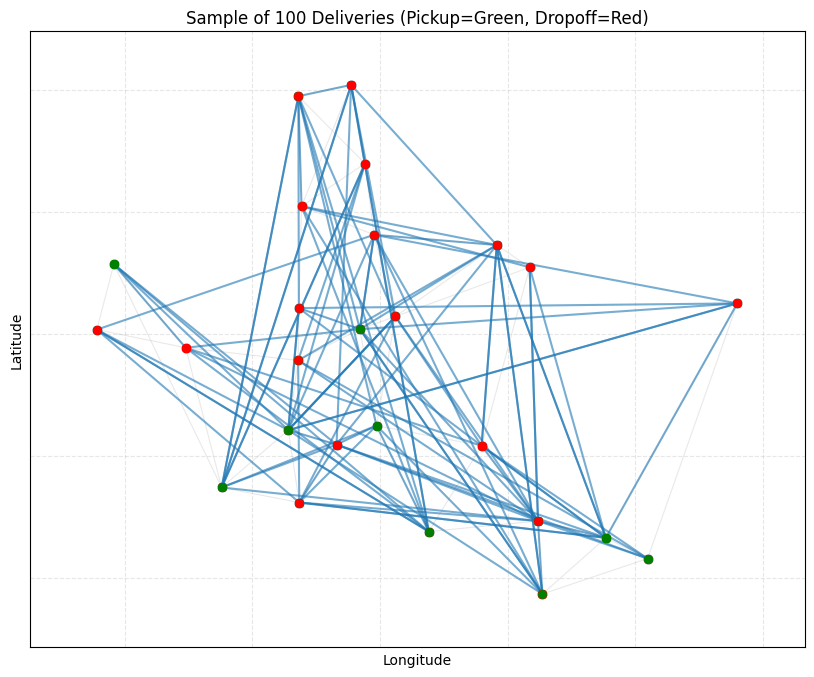

In [187]:
# Example usage (run after generating deliveries)
plot_deliveries_on_graph(G, deliveries, sample_size=100)

## MADDPG Agent and Agent Coordinator

In [188]:
# ------------------ Cell A: MADDPGAgent (PyTorch) + ReplayBuffer ------------------
# Requires: torch, nn, F, optim, numpy, random, collections (namedtuple, deque)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Transition = namedtuple('Transition', [
    'obs_self', 'obs_other',
    'action_self', 'action_other',
    'reward_self', 'reward_other',
    'next_obs_self', 'next_obs_other',
    'done'
])

class ReplayBuffer:
    def __init__(self, capacity=200000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, *args):
        self.buffer.append(Transition(*args))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))
    
    def __len__(self):
        return len(self.buffer)

# simple MLP factory
def mlp(input_dim, hidden_dims, output_dim, final_activation=None):
    layers = []
    prev = input_dim
    for h in hidden_dims:
        layers.append(nn.Linear(prev, h))
        layers.append(nn.ReLU())
        prev = h
    layers.append(nn.Linear(prev, output_dim))
    if final_activation == 'tanh':
        layers.append(nn.Tanh())
    return nn.Sequential(*layers)

class Actor(nn.Module):
    def __init__(self, obs_dim=3, hidden=(128,64)):
        super().__init__()
        self.net = mlp(obs_dim, hidden, 1)
    def forward(self, x):
        # x: (B, obs_dim)
        logits = self.net(x).squeeze(-1)   # (B,)
        prob = torch.sigmoid(logits)       # (B,)
        return prob

class Critic(nn.Module):
    def __init__(self, input_dim=8, hidden=(256,128)):
        super().__init__()
        self.net = mlp(input_dim, hidden, 1)
    def forward(self, x):
        return self.net(x).squeeze(-1)     # (B,)

class MADDPGAgent:
    """
    Per-agent Actor + per-agent Centralized Critic (observes paired obs+actions).
    Each agent instance is used for one driver; critic input is (obs_self, obs_other, act_self, act_other).
    """
    def __init__(self, obs_dim=3, lr_actor=1e-4, lr_critic=1e-3, gamma=0.99, tau=0.01):
        self.obs_dim = obs_dim
        self.gamma = gamma
        self.tau = tau
        
        # networks
        self.actor = Actor(obs_dim).to(device)
        self.actor_target = Actor(obs_dim).to(device)
        self.critic = Critic(input_dim=obs_dim*2 + 2).to(device)
        self.critic_target = Critic(input_dim=obs_dim*2 + 2).to(device)
        
        # optimizers
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)
        
        # sync targets
        self._hard_update(self.actor_target, self.actor)
        self._hard_update(self.critic_target, self.critic)
    
    def _hard_update(self, target, source):
        target.load_state_dict(source.state_dict())
    
    def soft_update(self):
        for target_param, param in zip(self.actor_target.parameters(), self.actor.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)
        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)
    
    def select_action(self, obs, deterministic=False, eps=0.0):
        """
        obs: numpy array (obs_dim,) or torch tensor or None.
        returns: action int 0/1 and prob float
        """
        if obs is None:
            return 0, 0.0

        # normalize types to numpy array / torch tensor as before
        if isinstance(obs, np.ndarray):
            obs_v = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        elif isinstance(obs, torch.Tensor):
            obs_v = obs.unsqueeze(0).to(device)
        else:
            obs_v = torch.tensor(np.array(obs), dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            prob = self.actor(obs_v).cpu().item()

        # safety: clip prob to [0,1]
        prob = float(min(1.0, max(0.0, prob)))

        # exploration: eps-greedy but deterministic returns still allowed
        if (not deterministic) and (random.random() < eps):
            # explicit two-way choice
            act = 1 if random.random() < 0.5 else 0
        else:
            # no jitter here — keep deterministic mapping clean and cast to int
            act = 1 if prob >= 0.5 else 0

        # DEBUG / sanity checks (will show if something upstream is corrupt)
        if not (act in (0, 1)):
            print(f"[DEBUG_SELECT_ACTION] invalid act={act} (type={type(act)}) prob={prob}")
        if not (0.0 <= prob <= 1.0):
            print(f"[DEBUG_SELECT_ACTION] prob out of range: {prob}")

        # ensure we return ints and Python floats (not numpy types)
        return int(act), float(prob)

    
    def _build_critic_input(self, obs_self, obs_other, act_self, act_other):
        # obs_*: (B, obs_dim) tensors, act_*: (B,1)
        return torch.cat([obs_self, obs_other, act_self, act_other], dim=-1)
    
    def update(self, batch: Transition):
        """
        One agent's update using a batch of paired transitions.
        batch fields are sequences from ReplayBuffer.sample.
        """
        if len(batch.obs_self) == 0:
            return None
        
        # convert to tensors
        obs_self = torch.tensor(np.stack(batch.obs_self), dtype=torch.float32, device=device)   # (B,obs_dim)
        obs_other = torch.tensor(np.stack(batch.obs_other), dtype=torch.float32, device=device)
        action_self = torch.tensor(np.array(batch.action_self).reshape(-1,1), dtype=torch.float32, device=device)
        action_other = torch.tensor(np.array(batch.action_other).reshape(-1,1), dtype=torch.float32, device=device)
        reward_self = torch.tensor(np.array(batch.reward_self), dtype=torch.float32, device=device)
        # reward_other = torch.tensor(np.array(batch.reward_other), dtype=torch.float32, device=device)
        next_obs_self = torch.tensor(np.stack([x if x is not None else np.zeros(self.obs_dim) for x in batch.next_obs_self]), dtype=torch.float32, device=device)
        next_obs_other = torch.tensor(np.stack([x if x is not None else np.zeros(self.obs_dim) for x in batch.next_obs_other]), dtype=torch.float32, device=device)
        done = torch.tensor(np.array(batch.done).astype(np.float32), dtype=torch.float32, device=device)
        
        batch_size = obs_self.shape[0]
        
        # ----- Critic update -----
        with torch.no_grad():
            next_prob_self = self.actor_target(next_obs_self).unsqueeze(-1)    # (B,1)
            next_prob_other = self.actor_target(next_obs_other).unsqueeze(-1)
            next_critic_input = self._build_critic_input(next_obs_self, next_obs_other, next_prob_self, next_prob_other)
            target_q = self.critic_target(next_critic_input)                # (B,)
            y = reward_self + (1.0 - done) * self.gamma * target_q
        
        critic_input = self._build_critic_input(obs_self, obs_other, action_self, action_other)
        current_q = self.critic(critic_input)
        critic_loss = F.mse_loss(current_q, y.detach())
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.critic_optimizer.step()
        
        # ----- Actor update -----
        prob_self = self.actor(obs_self).unsqueeze(-1)   # (B,1)
        act_other_batch = action_other.detach()          # treat other action as constant
        actor_critic_input = self._build_critic_input(obs_self, obs_other, prob_self, act_other_batch)
        actor_loss = -self.critic(actor_critic_input).mean()
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
        self.actor_optimizer.step()
        
        # soft update
        self.soft_update()
        
        return {'critic_loss': critic_loss.item(), 'actor_loss': actor_loss.item()}

In [189]:
# ------------------ Cell B: AgentCoordinator (PyTorch MADDPG loop) ------------------
# Assumes: DeliveryEnvironment env is defined and ReplayBuffer, MADDPGAgent are available.

class AgentCoordinator:
    def __init__(self, env, num_agents=None, buffer_capacity=500000, batch_size=1024,
                 update_after=5000, update_every=50, gamma=0.99, tau=0.01, seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
        self.env = env
        self.num_agents = num_agents or env.num_agents
        self.batch_size = batch_size
        self.update_after = update_after
        self.update_every = update_every
        
        self.buffer = ReplayBuffer(capacity=buffer_capacity)
        self.agents = [MADDPGAgent(obs_dim=3, gamma=gamma, tau=tau) for _ in range(self.num_agents)]
        
        # training bookkeeping
        self.total_steps = 0
        self.training_steps = 0
        self.log = []
    
    def collect_and_store(self, obs, actions, rewards, next_obs, done):
        """
        Store pairwise transitions for all ordered agent pairs (a,b) where both have non-None obs.
        This matches the per-agent centralized-critic update pattern where critic sees (self, other).
        """
        for a in range(self.num_agents):
            for b in range(self.num_agents):
                if a == b:
                    continue
                o_a = obs.get(a, None)
                o_b = obs.get(b, None)
                no_a = next_obs.get(a, None)
                no_b = next_obs.get(b, None)
                if o_a is None or o_b is None:
                    continue
                self.buffer.push(o_a, o_b, actions[a], actions[b], rewards[a], rewards[b], no_a, no_b, done)
    
    def step_episode(self, max_steps=500, train=True, eps_start=0.4, eps_end=0.05, eps_decay=0.998):
        obs = self.env.reset()
        eps = eps_start
        cum_rewards = np.zeros(self.num_agents, dtype=float)
        bundles_count = 0
        
        for t in range(max_steps):
            actions = {}
            action_probs = {}
            # select actions for agents in STATE_ONE (env._get_observations gives None for others)
            for aid in range(self.num_agents):
                ob = obs.get(aid, None)
                act, prob = self.agents[aid].select_action(ob, deterministic=not train, eps=eps)
                actions[aid] = act
                action_probs[aid] = prob
            
            # quick debug snapshot of actions just before env.step
            # print summary rather than huge dump
            # bad_actions = {k:v for k,v in actions.items() if v not in (0,1)}
            # if bad_actions:
            #     print("[DEBUG_ACTIONS] Non-binary actions found:", bad_actions)
            # # also print types/stats of actions to detect accidental arrays
            # types_summary = {k: type(v).__name__ for k,v in actions.items()}
            # print(f"[DEBUG_ACTIONS_SUMMARY] actions_count={len(actions)}, action_types_sample={list(types_summary.items())[:6]}")

            next_obs, rewards, done, info = self.env.step(actions, max_steps=max_steps)
            
            # collect and store transitions
            self.collect_and_store(obs, actions, rewards, next_obs, done)
            
            # accumulate stats
            for aid, r in rewards.items():
                cum_rewards[aid] += r
                # detect bundling reward (heuristic: >5 is likely bundling reward)
                if r > 5.0:
                    bundles_count += 1
            
            self.total_steps += 1
            
            # training updates
            if train and len(self.buffer) >= self.update_after and (self.total_steps % self.update_every == 0):
                # perform updates: sample and update each agent
                for _ in range(1):  # number of update rounds per scheduled time (tunable)
                    batch = self.buffer.sample(self.batch_size)
                    for agent in self.agents:
                        agent.update(batch)
                    self.training_steps += 1
            
            obs = next_obs
            eps = max(eps_end, eps * eps_decay)
            
            if done:
                break
        
        avg_reward = float(np.mean(cum_rewards))
        self.log.append({'steps': t+1, 'avg_reward': avg_reward, 'bundles': bundles_count, 'stats': info['episode_stats']})
        # print(f"[Episode] steps={t+1}, avg_reward={avg_reward:.3f}, bundles={bundles_count}, stats={info['episode_stats']}")
        return avg_reward, info
    
    def train(self, n_episodes=100, max_steps=500, train=True, log_every=5):
        """
        Train loop for MADDPG.

        Args:
            n_episodes: total episodes to run
            max_steps: max steps per episode
            train: whether agents are in training mode
            log_every: print a short summary every `log_every` episodes (int)
        Returns:
            list of (avg_reward, info) tuples for each episode
        """
        results = []
        for ep in range(1, n_episodes + 1):
            avg_r, info = self.step_episode(max_steps=max_steps, train=train)
            results.append((avg_r, info))

            # brief periodic logging to avoid spamming the notebook
            if (ep % log_every) == 0 or ep == n_episodes:
                s = info['episode_stats']
                print(f"Ep {ep:4d}: avgR={avg_r:6.3f}, deliveries={s['total_deliveries']}, bundles={s['bundles_created']}")

        return results


In [190]:
G.number_of_nodes()

26

## Training Loop

In [191]:
coord = AgentCoordinator(env)

In [192]:
# -------------------- Step 5: Full multi-episode MADDPG training --------------------
N_EPISODES = 10
MAX_STEPS = 100

results = coord.train(n_episodes=N_EPISODES, max_steps=MAX_STEPS, train=True, log_every=5)


Ep    5: avgR= 8.601, deliveries=9324, bundles=2653
Ep   10: avgR= 8.665, deliveries=9324, bundles=2700


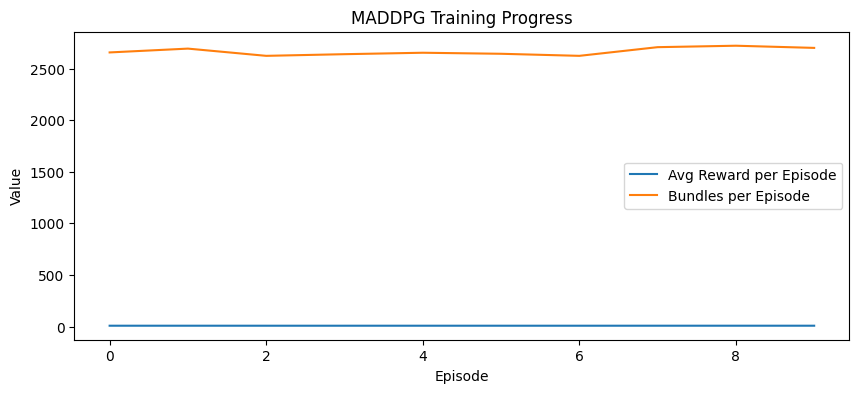

In [193]:
import matplotlib.pyplot as plt

avg_rewards = [r for r, _ in results]
bundles = [info['episode_stats']['bundles_created'] for _, info in results]

plt.figure(figsize=(10,4))
plt.plot(avg_rewards, label='Avg Reward per Episode')
plt.plot(bundles, label='Bundles per Episode')
plt.xlabel('Episode')
plt.ylabel('Value')
plt.title('MADDPG Training Progress')
plt.legend()
plt.show()

In [ ]:
def summarize_training(results):
    """
    Summary averaged over runs but printed as a single clean report.
    The 'Avg Distance Saved' printed here is computed as:
        Avg_Package_Distance - Avg_Driver_Distance
    which guarantees equality with your requested definition.
    """
    if not results:
        print("No results to summarize.")
        return

    stats = [info["episode_stats"] for _, info in results]

    # --- Success ---
    total_success = sum(s.get("successful_deliveries", 0) for s in stats)
    total_failed  = sum(s.get("failed_deliveries", 0) for s in stats)
    success_rate  = 100.0 * total_success / max(total_success + total_failed, 1)

    # --- Spawn -> delivery (lifetime) averaged per-run then averaged across runs ---
    per_run_lifetimes = []
    for s in stats:
        td = s.get("total_deliveries", 0)
        if td > 0:
            per_run_lifetimes.append(s.get("_sum_lifetime", 0.0) / td)
    avg_spawn_to_delivery = float(np.mean(per_run_lifetimes)) if per_run_lifetimes else 0.0

    # --- Bundles (average per run) ---
    bundles_per_run = [s.get("bundles_created", 0) for s in stats]
    avg_bundles = float(np.mean(bundles_per_run)) if bundles_per_run else 0.0

    # --- Driver & Package distances (average per run) ---
    driver_dists_per_run  = [s.get("total_driver_distance", 0.0) for s in stats]
    package_dists_per_run = [s.get("total_package_distance", 0.0) for s in stats]

    avg_driver_dist  = float(np.mean(driver_dists_per_run))  if driver_dists_per_run  else 0.0
    avg_package_dist = float(np.mean(package_dists_per_run)) if package_dists_per_run else 0.0

    # --- The single saved metric (guaranteed equality) ---
    avg_distance_saved = avg_package_dist - avg_driver_dist

    # --- Print final clean summary ---
    if baseline == "umst":
        print("\n----------- UMST SUMMARY -----------")
    else:
        print("\n----------- MADDPG SUMMARY -----------")

    print(f"Number of Drivers           {ndrivers}")
    print(f"Number of Deliveries        {ndeleveries}")
    print()
    print(f"Success Rate :              {success_rate:.2f}%")
    print(f"Avg Spawn -> Delivery Time: {avg_spawn_to_delivery:.2f} minutes")
    print()
    print(f"Average Bundles/Run:        {avg_bundles:.2f}")
    print()
    print(f"Avg Driver Distance:        {avg_driver_dist:.2f} km")
    print(f"Avg Package Distance:       {avg_package_dist:.2f} km")
    print(f"Avg Distance Saved:         {avg_distance_saved:.2f} km   (package - driver)")
    print("------------------------------------\n")


# Results

In [195]:
# Example usage:
summarize_training(results)


----------- MADDPG SUMMARY -----------
Number of Drivers           9000
Number of Deliveries        9324

Success Rate :              91.12%
Avg Spawn -> Delivery Time: 16.02 minutes

Average Bundles/Run:        2665.80

Avg Driver Distance:        47176.32 km
Avg Package Distance:       52949.98 km
Avg Distance Saved:         5773.65 km   (package - driver)
------------------------------------



,Metric,UMST,MADDPG
0,Success Rate (%),89.21,97.31
1,Avg Spawn->Delivery Time (min),16.87,10.60
2,Average Bundles/Run,3750.20,500.80
3,Total Driver Distance (km),45449.54,39427.10
4,Total Package Distance (km),52949.98,41546.97
5,Total Distance Saved (km) (package-driver),7500.44,2119.87


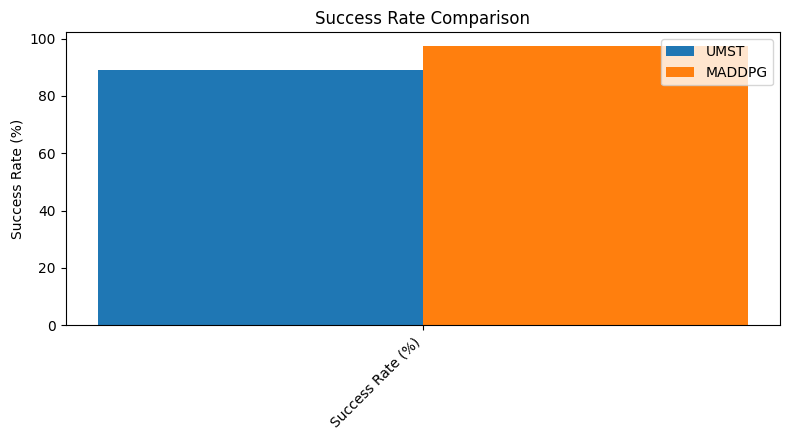

Saved: ./comparison_plots_out\success_rate.png


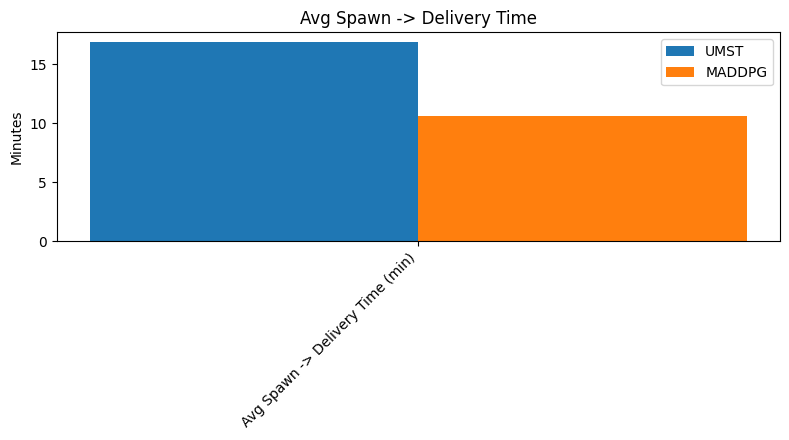

Saved: ./comparison_plots_out\spawn_delivery_time.png


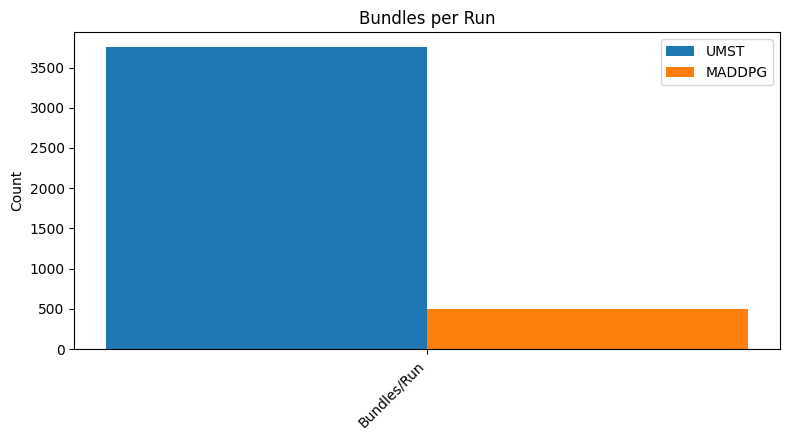

Saved: ./comparison_plots_out\bundles_per_run.png


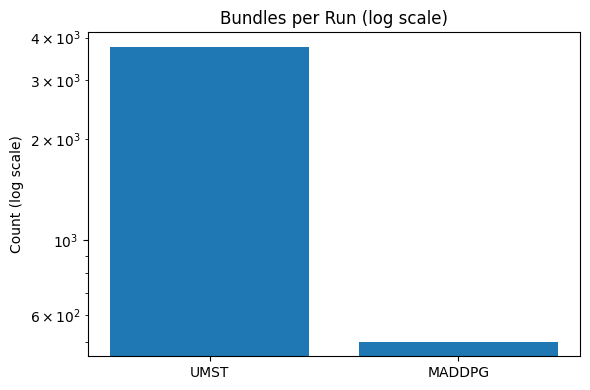

Saved: ./comparison_plots_out\bundles_per_run_log.png


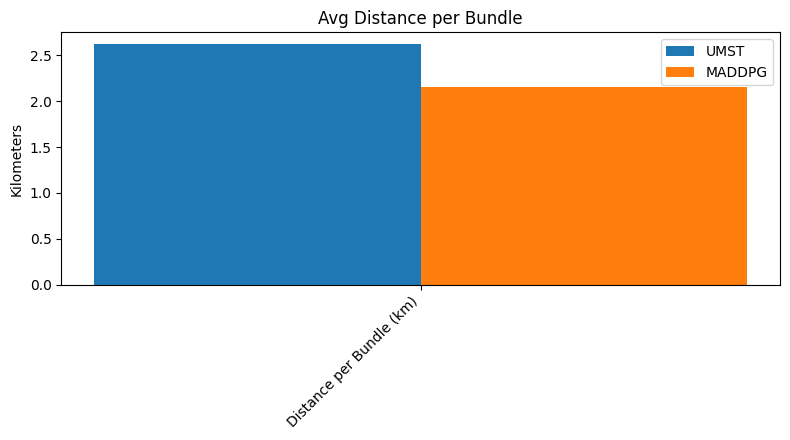

Saved: ./comparison_plots_out\dist_per_bundle.png


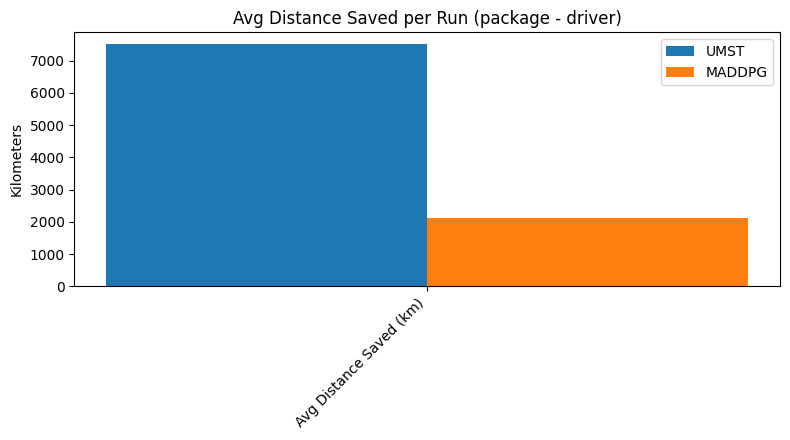

Saved: ./comparison_plots_out\dist_saved_per_run.png


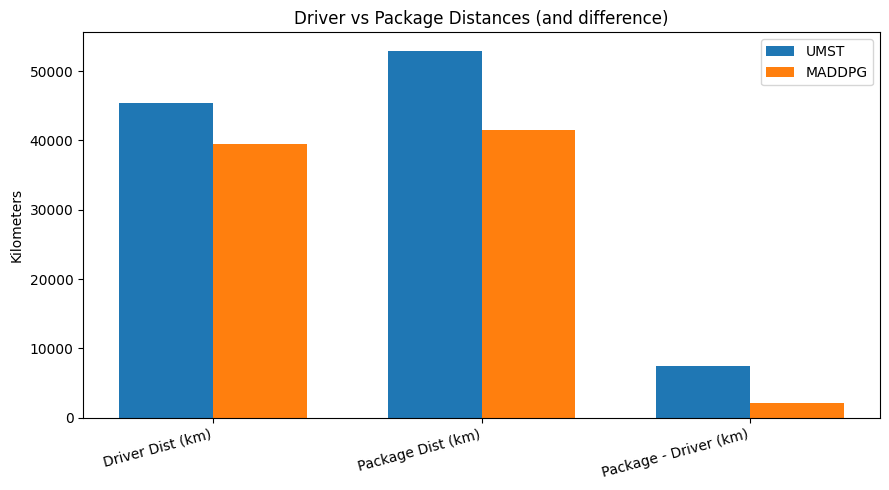

Saved: ./comparison_plots_out\driver_package_dist.png

All plots saved to: ./comparison_plots_out


In [196]:
# comparison_plots_edited.py
# Generates comparison plots for UMST vs MADDPG using the provided summary numbers.
# Requires: matplotlib, numpy, pandas (pandas optional)
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

OUT_DIR = "./comparison_plots_out"
os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------
# Hardcoded metrics (from your provided summaries)
# --------------------------
metrics = {
    'metric': [
        'Success Rate (%)',
        'Avg Spawn->Delivery Time (min)',
        'Average Bundles/Run',
        'Avg Distance Saved/Run (km) (package-driver)',
        'Avg Distance per Bundle (km)',
        'Avg Driver Distance (km)',
        'Avg Package Distance (km)',
        'Package - Driver Distance (km)'
    ],
    'UMST': {
        'success_rate': 89.21,
        'spawn_to_delivery': 16.87,
        'bundles_per_run': 3750.20,
        'dist_per_bundle': 2.62,
        'driver_distance': 45449.54,
        'package_distance': 52949.98
    },
    'MADDPG': {
        'success_rate': 97.31,
        'spawn_to_delivery': 10.60,
        'bundles_per_run': 500.80,
        'dist_per_bundle': 2.15,
        'driver_distance': 39427.10,
        'package_distance': 41546.97
    }
}

# Compute saved = package - driver (guaranteed equality to your summary)
saved_umst = metrics['UMST']['package_distance'] - metrics['UMST']['driver_distance']
saved_maddpg = metrics['MADDPG']['package_distance'] - metrics['MADDPG']['driver_distance']

# Build a simple DataFrame for inspection
df = pd.DataFrame({
    'Metric': [
        'Success Rate (%)',
        'Avg Spawn->Delivery Time (min)',
        'Average Bundles/Run',
        'Total Driver Distance (km)',
        'Total Package Distance (km)',
        'Total Distance Saved (km) (package-driver)'
    ],
    'UMST': [
        metrics['UMST']['success_rate'],
        metrics['UMST']['spawn_to_delivery'],
        metrics['UMST']['bundles_per_run'],
        metrics['UMST']['driver_distance'],
        metrics['UMST']['package_distance'],
        saved_umst
    ],
    'MADDPG': [
        metrics['MADDPG']['success_rate'],
        metrics['MADDPG']['spawn_to_delivery'],
        metrics['MADDPG']['bundles_per_run'],
        metrics['MADDPG']['driver_distance'],
        metrics['MADDPG']['package_distance'],
        saved_maddpg
    ]
})

# Optional: display in notebook (comment out if running as script)
try:
    from IPython.display import display
    display(df)
except Exception:
    pass

# --------------------------
# Helper for two-series grouped bar plot
# --------------------------
def draw_bar_comparison(x_labels, vals1, vals2, title, ylabel, filename):
    x = np.arange(len(x_labels))
    width = 0.35
    plt.figure(figsize=(8, 4.5))
    plt.bar(x - width/2, vals1, width)
    plt.bar(x + width/2, vals2, width)
    plt.xticks(x, x_labels, rotation=45, ha='right')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(['UMST', 'MADDPG'])
    plt.tight_layout()
    path = os.path.join(OUT_DIR, filename)
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print("Saved:", path)

# 1) Success Rate
draw_bar_comparison(['Success Rate (%)'],
                    [metrics['UMST']['success_rate']],
                    [metrics['MADDPG']['success_rate']],
                    'Success Rate Comparison',
                    'Success Rate (%)',
                    'success_rate.png')

# 2) Avg Spawn -> Delivery Time
draw_bar_comparison(['Avg Spawn -> Delivery Time (min)'],
                    [metrics['UMST']['spawn_to_delivery']],
                    [metrics['MADDPG']['spawn_to_delivery']],
                    'Avg Spawn -> Delivery Time',
                    'Minutes',
                    'spawn_delivery_time.png')

# 3) Bundles per run (linear)
draw_bar_comparison(['Bundles/Run'],
                    [metrics['UMST']['bundles_per_run']],
                    [metrics['MADDPG']['bundles_per_run']],
                    'Bundles per Run',
                    'Count',
                    'bundles_per_run.png')

# 3b) Bundles per run (log scale) - useful because of large difference
plt.figure(figsize=(6,4))
plt.bar([0,1], [metrics['UMST']['bundles_per_run'], metrics['MADDPG']['bundles_per_run']])
plt.xticks([0,1], ['UMST','MADDPG'])
plt.yscale('log')
plt.title('Bundles per Run (log scale)')
plt.ylabel('Count (log scale)')
plt.tight_layout()
p = os.path.join(OUT_DIR, 'bundles_per_run_log.png')
plt.savefig(p, dpi=150)
plt.show()
plt.close()
print("Saved:", p)

# 4) Avg Distance per Bundle
draw_bar_comparison(['Distance per Bundle (km)'],
                    [metrics['UMST']['dist_per_bundle']],
                    [metrics['MADDPG']['dist_per_bundle']],
                    'Avg Distance per Bundle',
                    'Kilometers',
                    'dist_per_bundle.png')

# 5) Avg Distance Saved (package - driver) per run
draw_bar_comparison(['Avg Distance Saved (km)'],
                    [saved_umst],
                    [saved_maddpg],
                    'Avg Distance Saved per Run (package - driver)',
                    'Kilometers',
                    'dist_saved_per_run.png')

# 6) Driver vs Package vs Package-Driver (grouped)
labels = ['Driver Dist (km)', 'Package Dist (km)', 'Package - Driver (km)']
vals_umst = [metrics['UMST']['driver_distance'], metrics['UMST']['package_distance'], saved_umst]
vals_maddpg = [metrics['MADDPG']['driver_distance'], metrics['MADDPG']['package_distance'], saved_maddpg]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(9,5))
plt.bar(x - width/2, vals_umst, width)
plt.bar(x + width/2, vals_maddpg, width)
plt.xticks(x, labels, rotation=15, ha='right')
plt.ylabel('Kilometers')
plt.title('Driver vs Package Distances (and difference)')
plt.legend(['UMST', 'MADDPG'])
plt.tight_layout()
p2 = os.path.join(OUT_DIR, 'driver_package_dist.png')
plt.savefig(p2, dpi=150)
plt.show()
plt.close()
print("Saved:", p2)

print("\nAll plots saved to:", OUT_DIR)
